In [10]:
# Data Analysis Project - Titanic
# Objective: Explore dataset, find insights, build simple model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Cleaning Plan

- **Columns to drop**
  - PassengerId → irrelevant unique identifier, no predictive value.
  - Name → too granular, not useful for modeling.
  - Ticket → messy string, not standardized.
  - Cabin → mostly missing, unreliable.

- **Handling missing values**
  - Age → impute with median (robust to outliers).
  - Embarked → impute with mode (most common port).
  - Cabin → drop column entirely (too sparse).

- **Type conversions**
  - Sex → convert to categorical (male/female).
  - Embarked → convert to categorical (C/Q/S).
  - Survived → keep as integer (target variable).


In [12]:
# Example: drop PassengerId
df = df.drop(columns=["PassengerId"])

# Convert categorical to category type
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")


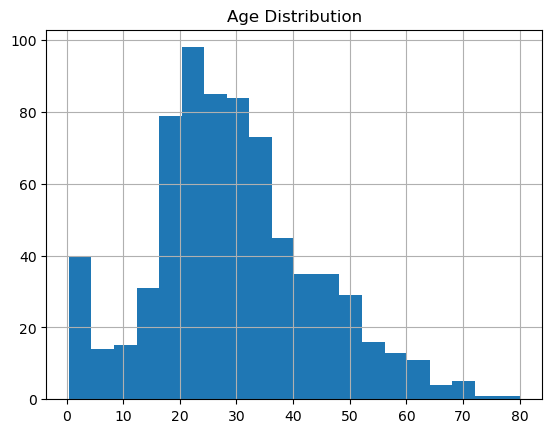

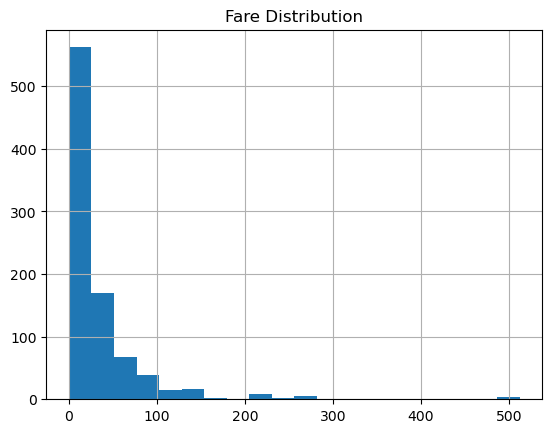

In [13]:
df["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.show()

df["Fare"].hist(bins=20)
plt.title("Fare Distribution")
plt.show()


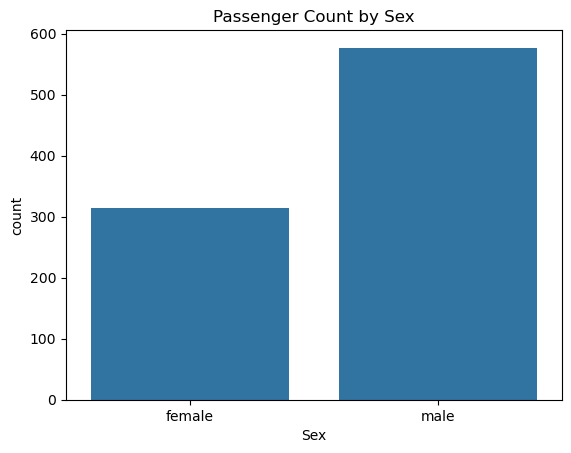

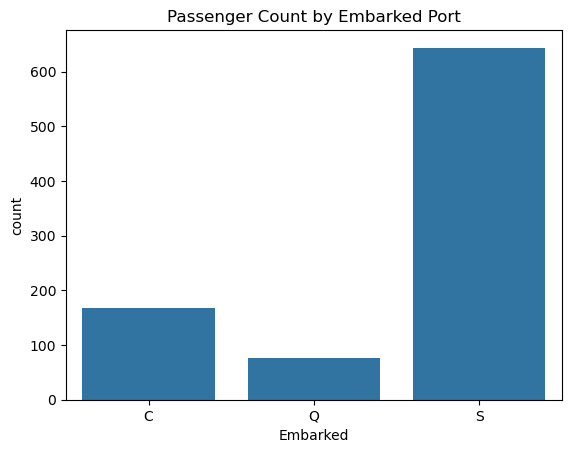

In [14]:
sns.countplot(x="Sex", data=df)
plt.title("Passenger Count by Sex")
plt.show()

sns.countplot(x="Embarked", data=df)
plt.title("Passenger Count by Embarked Port")
plt.show()


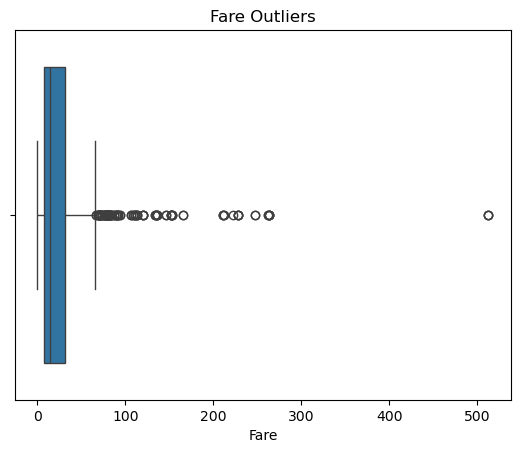

In [15]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()


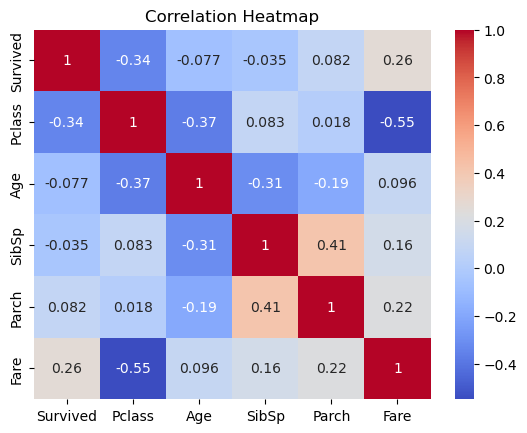

In [16]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
